Running MOEA/D...

MOEA/D Pareto Front
Pareto size = 16

--- Solution 1 ---
Makespan = 309.95
Carbon   = 773.22
Truck 1: [0, 57, 96, 11, 14, 95, 13, 27, 12, 41, 73, 98, 85, 88, 63, 74, 78, 64, 30, 15, 71, 35, 31, 17, 20, 19, 40, 16, 18, 91, 21, 33, 37, 68, 39, 56, 84, 23, 22, 1, 34, 99, 2, 25, 0]
Drone 1: [19, 33, 95, 98]
Truck 2: [0, 43, 0]
Drone 2: [43]
Truck 3: [0, 50, 92, 62, 48, 0]
Drone 3: []
Truck 4: [0, 77, 58, 82, 86, 67, 72, 70, 54, 36, 3, 32, 79, 51, 53, 4, 0]
Drone 4: [79]
Truck 5: [0, 80, 66, 94, 49, 45, 24, 90, 65, 6, 87, 52, 29, 5, 60, 61, 97, 75, 81, 100, 93, 8, 0]
Drone 5: [8]
Truck 6: [0, 46, 7, 42, 76, 9, 55, 28, 69, 47, 38, 44, 59, 26, 10, 89, 83, 0]
Drone 6: [76, 83]

--- Solution 2 ---
Makespan = 229.61
Carbon   = 825.65
Truck 1: [0, 13, 27, 12, 73, 41, 95, 57, 81, 9, 76, 42, 7, 46, 28, 0]
Drone 1: [13, 28, 42]
Truck 2: [0, 10, 89, 69, 47, 38, 44, 59, 26, 96, 83, 11, 14, 98, 85, 88, 63, 74, 78, 64, 30, 15, 71, 0]
Drone 2: []
Truck 3: [0, 35, 40, 16, 31, 17, 19, 18

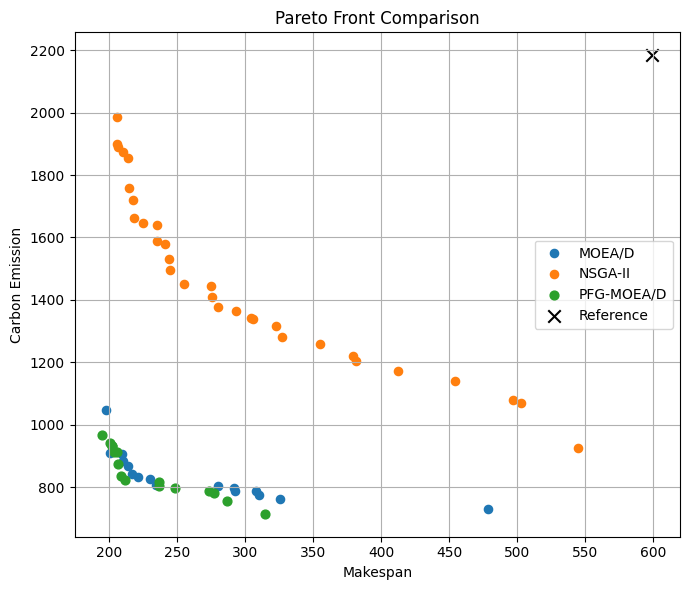

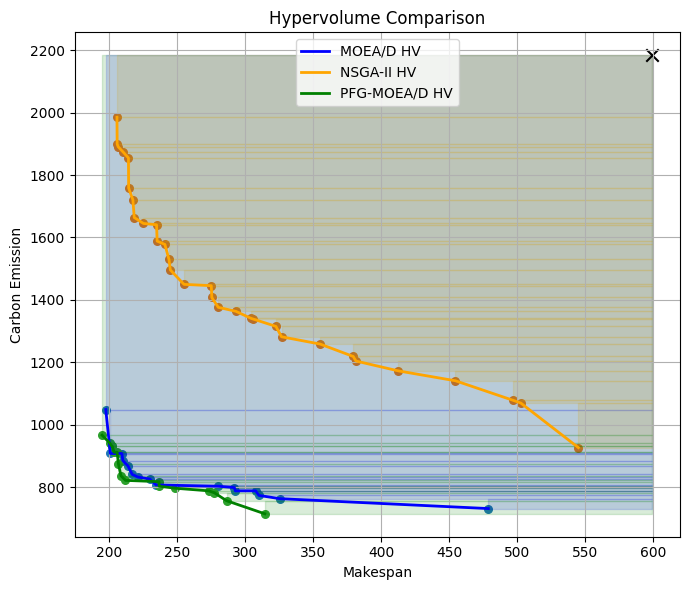

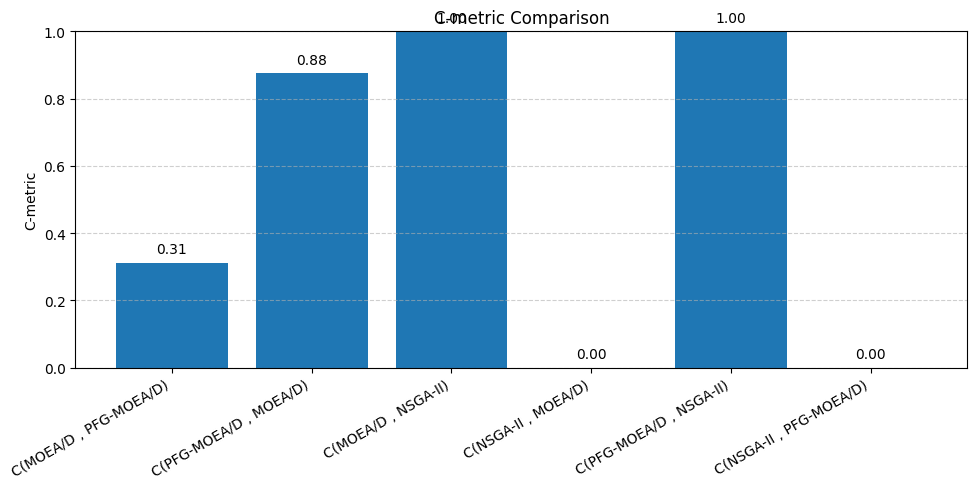

In [1]:
# IMPORT
import os
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from algorithm.moead_solver import MOEADSolver
from algorithm.pfg_moead_solver import PFGMOEADSolver
from algorithm.nsgaii_solver import NSGA2Solver


from metric.cmetric import c_metric
from metric.hv import hypervolume
from model.customer import Customer
import time

# CONFIG 
SEED = 1
POP_SIZE = 100
NUM_TRUCKS = 6

# Time Budget (seconds)
MAX_TIME = 1800

RESULT_DIR = "results_3algo_seed"
os.makedirs(RESULT_DIR, exist_ok=True)

DATA_FILE = "data/h100c101.csv"

def load_customers_from_csv(csv_path):
    df = pd.read_csv(csv_path)

    customers = {}

    # DEPOT (row 0, id = 0)
    depot = df.iloc[0]

    customers[0] = Customer(
        cid=0,
        x=float(depot["x"]),
        y=float(depot["y"]),
        demand=0.0,
        ready_time=float(depot["open"]),
        due_time=float(depot["close"]),
        service_time=0.0,
        drone_serve=False,   # depot KHÔNG phải khách drone
        time=float(depot["time"])
    )

    # CUSTOMERS (row 1..N, id = 1..N)
    for idx in range(1, len(df)):
        r = df.iloc[idx]
        cid = idx   # rất quan trọng: KHỚP với route [1..N]

        customers[cid] = Customer(
            cid=cid,
            x=float(r["x"]),
            y=float(r["y"]),
            demand=float(r["demand"]),
            ready_time=float(r["open"]),
            due_time=float(r["close"]),
            service_time=float(r["servicetime"]),
            drone_serve=bool(r["drone_serve"]),
            time=float(r["time"])
        )

    return customers


customers = load_customers_from_csv(DATA_FILE)


# UTILS
def pf_to_array(pf):
    return np.array([[s.makespan, s.carbonEmission] for s in pf])


def safe_drone_list(drone):
    if isinstance(drone, list):
        return [set(d) for d in drone]
    elif isinstance(drone, set):
        return [set(drone)]
    return []


def print_pareto(pf, title):
    print("\n" + "=" * 80)
    print(title)
    print(f"Pareto size = {len(pf)}")
    print("=" * 80)

    for i, s in enumerate(pf, 1):
        print(f"\n--- Solution {i} ---")
        print(f"Makespan = {s.makespan:.2f}")
        print(f"Carbon   = {s.carbonEmission:.2f}")

        drones = safe_drone_list(s.droneCustomers)

        for t, route in enumerate(s.truckRoutes):
            d = sorted(drones[t]) if t < len(drones) else []
            print(f"Truck {t+1}: {route}")
            print(f"Drone {t+1}: {d}")


def save_pareto_txt(pf, filepath, title):
    with open(filepath, "w") as f:
        f.write(title + "\n")
        f.write("=" * 80 + "\n\n")

        for i, s in enumerate(pf, 1):
            f.write(f"--- Solution {i} ---\n")
            f.write(f"Makespan = {s.makespan:.2f}\n")
            f.write(f"Carbon   = {s.carbonEmission:.2f}\n")

            drones = safe_drone_list(s.droneCustomers)

            for t, route in enumerate(s.truckRoutes):
                d = sorted(drones[t]) if t < len(drones) else []
                f.write(f"Truck {t+1}: {route}\n")
                f.write(f"Drone {t+1}: {d}\n")

            f.write("\n")

def export_pareto_csv(pf, algo_name, result_dir):
    rows = []

    for sid, s in enumerate(pf, 1):
        drones = safe_drone_list(s.droneCustomers)

        for t, route in enumerate(s.truckRoutes):
            d = sorted(drones[t]) if t < len(drones) else []

            rows.append({
                "solution_id": sid,
                "algorithm": algo_name,
                "makespan": s.makespan,
                "carbon": s.carbonEmission,
                "truck_id": t + 1,
                "truck_route": route,
                "drone_customers": d
            })

    df = pd.DataFrame(rows)
    csv_path = os.path.join(result_dir, f"{algo_name}_pareto.csv")
    df.to_csv(csv_path, index=False)


def plot_hv_area(front, ref, color, label):
    front = front[np.argsort(front[:, 0])]
    prev_y = ref[1]

    for f1, f2 in front:
        plt.fill_between(
            [f1, ref[0]],
            [f2, f2],
            [prev_y, prev_y],
            color=color,
            alpha=0.15
        )
        prev_y = f2

    plt.plot(front[:, 0], front[:, 1],
             color=color, linewidth=2, label=label)

def visualize_solution(solution, customers, title, solution_id=None):
    """
    Visualize one VRP-D solution (geometry-based).

    - Each truck: one unique color
    - Drone: same color as its truck, dashed line
    - Depot: black square
    - Customer: exact coordinates + customer ID
    """

    plt.figure(figsize=(9, 9))

    # ---------------- Customers ----------------
    for cid, c in customers.items():
        if cid == 0:
            continue

        plt.scatter(c.x, c.y, c="gray", s=25, alpha=0.7, zorder=2)
        plt.text(
            c.x + 0.4,
            c.y + 0.4,
            str(cid),
            fontsize=7,
            color="black",
            zorder=3
        )

    # ---------------- Depot ----------------
    depot = customers[0]
    plt.scatter(
        depot.x,
        depot.y,
        c="black",
        s=180,
        marker="s",
        zorder=5
    )
    plt.text(
        depot.x + 0.6,
        depot.y + 0.6,
        "Depot",
        fontsize=9,
        fontweight="bold"
    )

    cmap = plt.get_cmap("tab10")

    # ================= DRAW ROUTES =================
    for t, route in enumerate(solution.truckRoutes):

        color = cmap(t % 10)
        drone_set = solution.droneCustomers[t]

        # ---- Truck route (REMOVE drone customers like evaluator) ----
        truck_stops = [0]
        for cid in route[1:-1]:
            if cid not in drone_set:
                truck_stops.append(cid)
        truck_stops.append(0)

        tx = [customers[cid].x for cid in truck_stops]
        ty = [customers[cid].y for cid in truck_stops]

        plt.plot(
            tx,
            ty,
            color=color,
            linewidth=2.2,
            zorder=4,
            label=f"Truck {t+1}"
        )

        # ---- Drone jobs (launch -> cid -> recover) ----
        rlen = len(route)

        for pos in range(1, rlen - 1):

            cid = route[pos]
            if cid not in drone_set:
                continue

            # ===== FIND LAUNCH =====
            launch = next(
                route[p] for p in range(pos - 1, -1, -1)
                if route[p] == 0 or route[p] not in drone_set
            )

            # ===== FIND RECOVER =====
            recover = next(
                route[p] for p in range(pos + 1, rlen)
                if route[p] == 0 or route[p] not in drone_set
            )

            # ---- launch -> drone customer ----
            plt.plot(
                [customers[launch].x, customers[cid].x],
                [customers[launch].y, customers[cid].y],
                linestyle="--",
                linewidth=1.6,
                color=color,
                zorder=3
            )

            # ---- drone customer -> recover ----
            plt.plot(
                [customers[cid].x, customers[recover].x],
                [customers[cid].y, customers[recover].y],
                linestyle="--",
                linewidth=1.6,
                color=color,
                zorder=3
            )

    # ---------------- Legend ----------------
    legend_items = [
        Line2D([0], [0], marker='o', color='w',
               markerfacecolor='gray', markersize=8, label='Customer'),
        Line2D([0], [0], marker='s', color='w',
               markerfacecolor='black', markersize=10, label='Depot'),
        Line2D([0], [0], color='black', lw=2, label='Truck route'),
        Line2D([0], [0], color='black', lw=2,
               linestyle='--', label='Drone delivery')
    ]

    final_title = title
    if solution_id is not None:
        final_title += f"\n(Solution #{solution_id})"

    plt.title(final_title)
    plt.xlabel("X coordinate")
    plt.ylabel("Y coordinate")
    plt.legend(handles=legend_items, loc="best")
    plt.grid(True)
    plt.axis("equal")
    plt.tight_layout()
    plt.show()


# RUN MOEA/D (TIME-BASED)
print("Running MOEA/D...")

moead = MOEADSolver(
    pop_size=POP_SIZE,
    max_time=MAX_TIME,
    num_trucks=NUM_TRUCKS,
    customers=customers,
    seed=SEED
)

start_time1 = time.time()
pf_m = moead.run()
end_time1 = time.time()
print_pareto(pf_m, "MOEA/D Pareto Front")
export_pareto_csv(pf_m, "MOEAD", RESULT_DIR)
print(end_time1 - start_time1)

# RUN NSGA-II (TIME-BASED)
print("\nRunning NSGA-II...")

nsga = NSGA2Solver(
    pop_size=POP_SIZE,
    max_time=MAX_TIME,
    num_trucks=NUM_TRUCKS,
    customers=customers,
    seed=SEED
)

start_time3 = time.time()
pf_n = nsga.run()
end_time3 = time.time()

print_pareto(pf_n, "NSGA-II Pareto Front")
export_pareto_csv(pf_n, "NSGAII", RESULT_DIR)
print(end_time3 - start_time3)

# RUN PFG-MOEA/D (TIME-BASED)
print("\nRunning PFG-MOEA/D...")

pfg = PFGMOEADSolver(
    pop_size=POP_SIZE,
    max_time=MAX_TIME,
    num_trucks=NUM_TRUCKS,
    customers=customers,
    seed=SEED
)
start_time2 = time.time()
pf_p = pfg.run()
end_time2 = time.time()
print_pareto(pf_p, "PFG-MOEA/D Pareto Front")
export_pareto_csv(pf_p, "PFG_MOEAD", RESULT_DIR)
print(end_time2 - start_time2)

# PREPARE DATA
arr_m = pf_to_array(pf_m)
arr_p = pf_to_array(pf_p)
arr_n = pf_to_array(pf_n)

all_points = np.vstack([arr_m, arr_p, arr_n])

ref = np.array([
    all_points[:, 0].max() * 1.1,
    all_points[:, 1].max() * 1.1
])


# METRICS
hv_m = hypervolume(pf_m, tuple(ref))
hv_p = hypervolume(pf_p, tuple(ref))
hv_n = hypervolume(pf_n, tuple(ref))

# ---- 6 C-metric ----
c_m_p = c_metric(pf_m, pf_p)
c_p_m = c_metric(pf_p, pf_m)

c_m_n = c_metric(pf_m, pf_n)
c_n_m = c_metric(pf_n, pf_m)

c_p_n = c_metric(pf_p, pf_n)
c_n_p = c_metric(pf_n, pf_p)

print("\n=== METRICS ===")
print(f"HV(MOEA/D) = {hv_m:.6f}")
print(f"HV(NSGA-II) = {hv_n:.6f}")
print(f"HV(PFG-MOEA/D) = {hv_p:.6f}")

print("\n--- C-METRIC ---")
print(f"C(MOEA/D , PFG-MOEA/D) = {c_m_p:.3f}")
print(f"C(PFG-MOEA/D , MOEA/D) = {c_p_m:.3f}")

print(f"C(MOEA/D , NSGA-II) = {c_m_n:.3f}")
print(f"C(NSGA-II , MOEA/D) = {c_n_m:.3f}")

print(f"C(PFG-MOEA/D , NSGA-II) = {c_p_n:.3f}")
print(f"C(NSGA-II , PFG-MOEA/D) = {c_n_p:.3f}")


with open(os.path.join(RESULT_DIR, "metrics.txt"), "w") as f:
    f.write(f"MAX_TIME {MAX_TIME}\n\n")

    f.write(f"HV(MOEA/D) {hv_m}\n")
    f.write(f"HV(NSGA-II) {hv_n}\n")
    f.write(f"HV(PFG-MOEA/D) {hv_p}\n\n")

    f.write("C_METRIC\n")
    f.write(f"C(MOEA/D , PFG-MOEA/D) {c_m_p}\n")
    f.write(f"C(PFG-MOEA/D , MOEA/D) {c_p_m}\n")

    f.write(f"C(MOEA/D , NSGA-II) {c_m_n}\n")
    f.write(f"C(NSGA-II , MOEA/D) {c_n_m}\n")

    f.write(f"C(PFG-MOEA/D , NSGA-II) {c_p_n}\n")
    f.write(f"C(NSGA-II , PFG-MOEA/D) {c_n_p}\n")


# FIGURE 1: PARETO FRONT
plt.figure(figsize=(7, 6))

plt.scatter(arr_m[:, 0], arr_m[:, 1], s=35, label="MOEA/D")
plt.scatter(arr_n[:, 0], arr_n[:, 1], s=35, label="NSGA-II")
plt.scatter(arr_p[:, 0], arr_p[:, 1], s=40, label="PFG-MOEA/D")

plt.scatter(ref[0], ref[1], c="black", marker="x", s=80, label="Reference")

plt.xlabel("Makespan")
plt.ylabel("Carbon Emission")
plt.title("Pareto Front Comparison")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(RESULT_DIR, "pareto_front.png"), dpi=300)
plt.show()


# FIGURE 2: HYPERVOLUME AREA
plt.figure(figsize=(7, 6))

plt.scatter(arr_m[:, 0], arr_m[:, 1], s=30)
plt.scatter(arr_n[:, 0], arr_n[:, 1], s=30)
plt.scatter(arr_p[:, 0], arr_p[:, 1], s=30)

plot_hv_area(arr_m, ref, "blue", "MOEA/D HV")
plot_hv_area(arr_n, ref, "orange", "NSGA-II HV")
plot_hv_area(arr_p, ref, "green", "PFG-MOEA/D HV")

plt.scatter(ref[0], ref[1], c="black", marker="x", s=80)

plt.xlabel("Makespan")
plt.ylabel("Carbon Emission")
plt.title("Hypervolume Comparison")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(RESULT_DIR, "hypervolume.png"), dpi=300)
plt.show()


# FIGURE 3: C-METRIC
labels = [
    "C(MOEA/D , PFG-MOEA/D)",
    "C(PFG-MOEA/D , MOEA/D)",
    "C(MOEA/D , NSGA-II)",
    "C(NSGA-II , MOEA/D)",
    "C(PFG-MOEA/D , NSGA-II)",
    "C(NSGA-II , PFG-MOEA/D)"
]

values = [
    c_m_p,
    c_p_m,
    c_m_n,
    c_n_m,
    c_p_n,
    c_n_p
]

plt.figure(figsize=(10, 5))
bars = plt.bar(labels, values)

for bar in bars:
    y = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        y + 0.02,
        f"{y:.2f}",
        ha="center",
        va="bottom"
    )

plt.ylim(0, 1)
plt.ylabel("C-metric")
plt.title("C-metric Comparison")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig(os.path.join(RESULT_DIR, "cmetric.png"), dpi=300)
plt.show()


In [2]:
print(f"\n[SUMMARY] Computational Efficiency (Time Budget: {MAX_TIME}s)")
print(f"NSGAII ran for {nsga.generations} generations within {MAX_TIME} seconds.")
print(f"MOEA/D ran for {moead.generations} generations within {MAX_TIME} seconds.")
print(f"PFG-MOEA/D ran for {pfg.generations} generations within {MAX_TIME} seconds.")


[SUMMARY] Computational Efficiency (Time Budget: 1800s)
NSGAII ran for 592 generations within 1800 seconds.
MOEA/D ran for 1684 generations within 1800 seconds.
PFG-MOEA/D ran for 1443 generations within 1800 seconds.


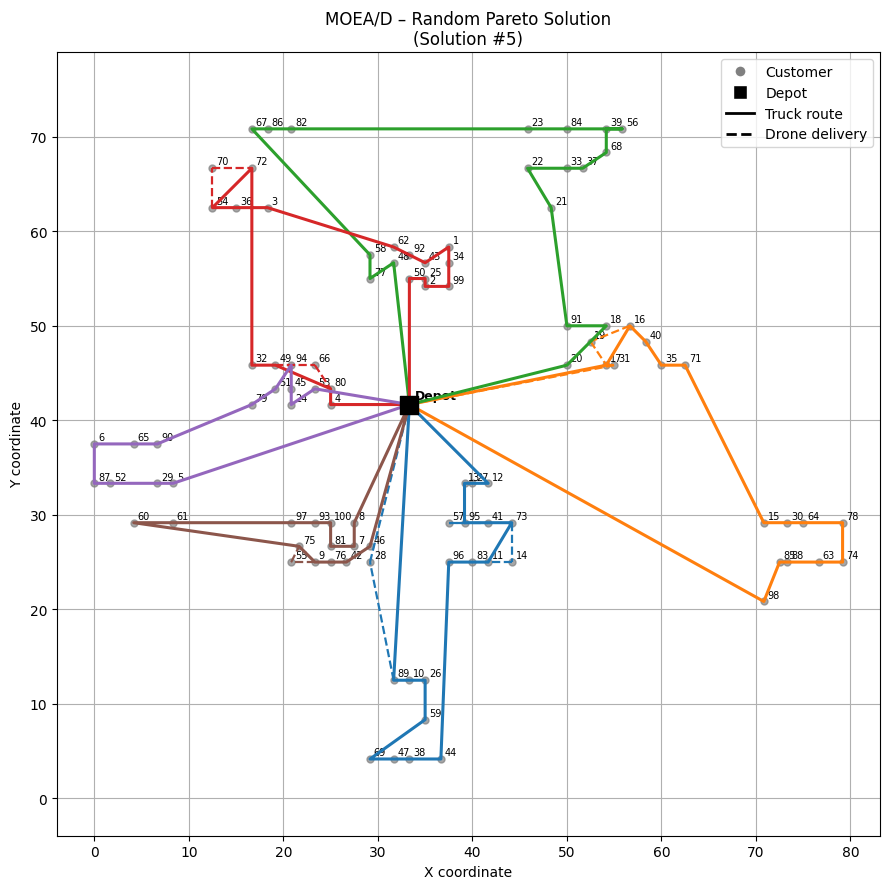

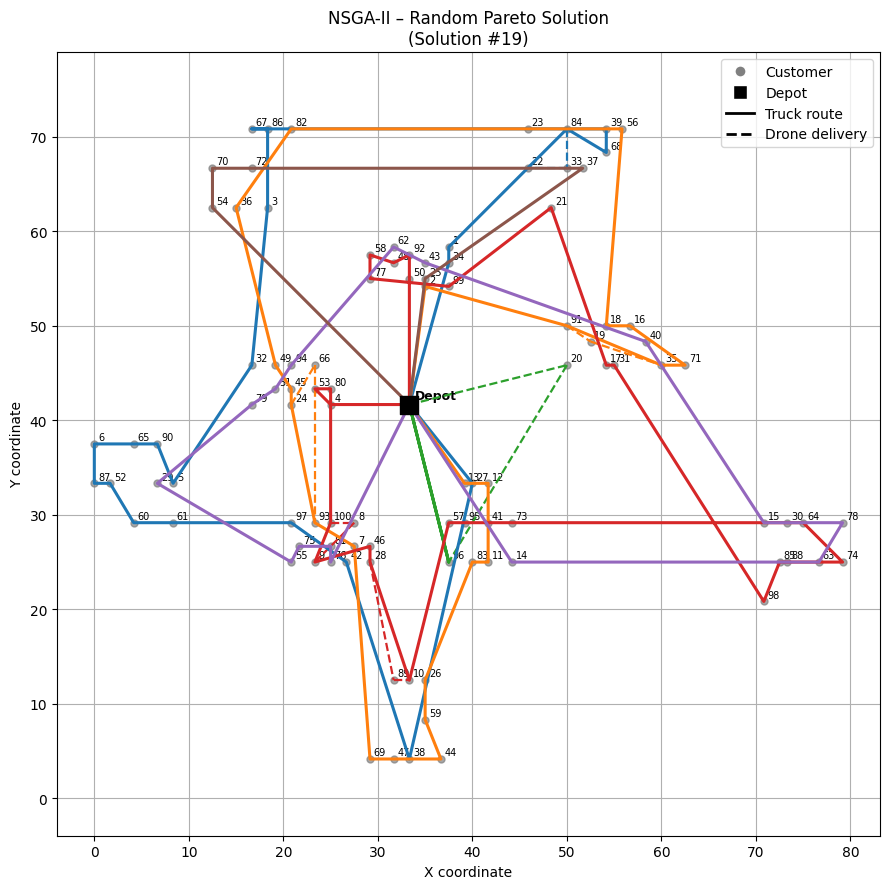

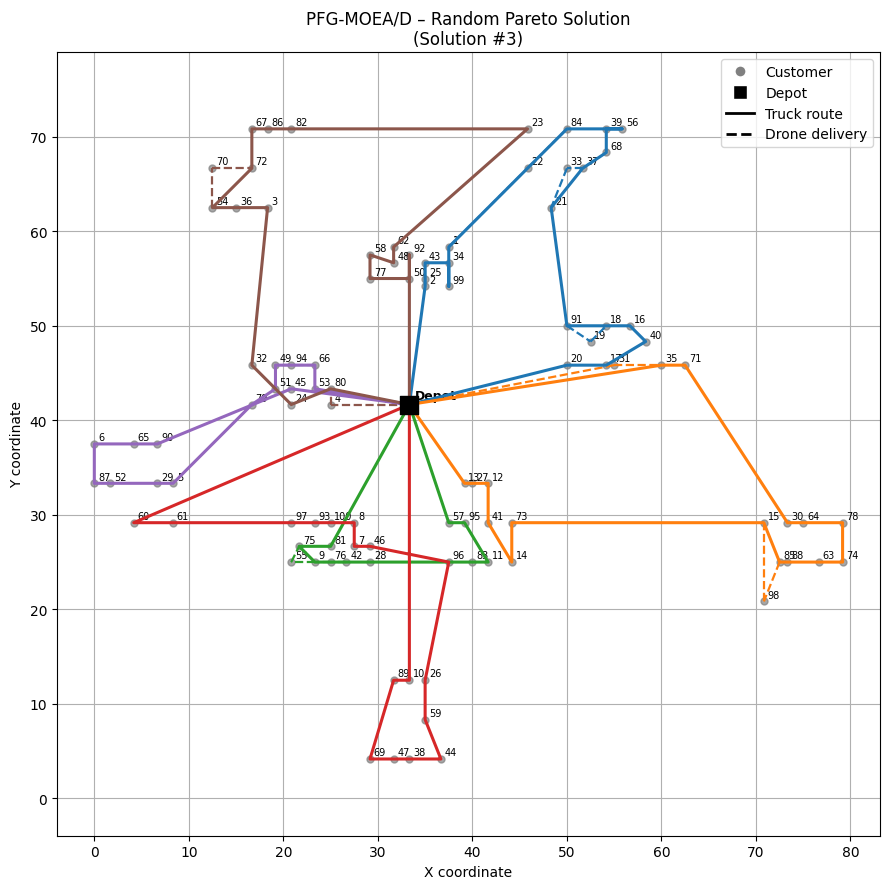

In [3]:
random.seed(SEED)

sid_m = random.randint(1, len(pf_m))
sid_n = random.randint(1, len(pf_n))
sid_p = random.randint(1, len(pf_p))

visualize_solution(
    pf_m[sid_m - 1],
    customers,
    "MOEA/D – Random Pareto Solution",
    solution_id=sid_m
)

visualize_solution(
    pf_n[sid_n - 1],
    customers,
    "NSGA-II – Random Pareto Solution",
    solution_id=sid_n
)

visualize_solution(
    pf_p[sid_p - 1],
    customers,
    "PFG-MOEA/D – Random Pareto Solution",
    solution_id=sid_p
)